# 🤖 Who Gets the Job? Cracking AI Resume Screening with ML
## A Classification Deep-Dive into the 2026 AI Hiring Dataset

---

> *"In 2026, your first interview is with an algorithm — not a human."*
> This notebook reverse-engineers what that algorithm actually cares about.

---

### 🎯 What This Notebook Covers

| # | Section | Focus |
|---|---------|-------|
| 1 | 📦 Setup & Load | Libraries, data audit |
| 2 | 🔍 EDA | Score distributions, selection rates, correlations |
| 3 | ⚙️ Feature Engineering | Composite scores, salary parsing, experience tiers |
| 4 | 🏁 Baseline Benchmarking | 5 models, 5-fold CV, AUC comparison |
| 5 | 🎛️ Hyperparameter Tuning | RandomizedSearchCV on best model |
| 6 | 📊 Evaluation | ROC, PR curve, confusion matrix |
| 7 | 🔎 SHAP Explainability | What actually drives the AI decision |
| 8 | 🎚️ Threshold Optimization | F1-maximising decision boundary |
| 9 | 💡 Key Findings | Insights for candidates, employers & researchers |

---

### 📁 Dataset
**AI Resume Screening & Job Market Dataset (2026)** — synthetic records of candidates, AI-scored resumes, job roles, and final hiring outcomes.

**Target variable:** `ai_screening_result` → `Selected` or `Rejected`

---

---
## 📦 Section 1 — Setup & Data Loading
---

In [ ]:
# ══════════════════════════════════════════════════════════════
#  IMPORTS & GLOBAL STYLE
# ══════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Dark cyberpunk theme — consistent across all charts
plt.rcParams.update({
    'figure.facecolor' : '#0d0d1a',
    'axes.facecolor'   : '#0d0d1a',
    'axes.edgecolor'   : '#2a2a4a',
    'axes.labelcolor'  : '#b0b0d0',
    'xtick.color'      : '#b0b0d0',
    'ytick.color'      : '#b0b0d0',
    'text.color'       : '#e0e0ff',
    'grid.color'       : '#1e1e3a',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.6,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 14,
    'axes.titleweight' : 'bold',
    'axes.titlepad'    : 12,
    'figure.titlesize' : 16,
})

PALETTE = ['#7B61FF', '#FF6B9D', '#00D9C0', '#FFB347', '#64B5F6', '#A8FF78']
sns.set_palette(PALETTE)

# ── ML ────────────────────────────────────────────────────────
from sklearn.model_selection   import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing     import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.pipeline          import Pipeline
from sklearn.compose           import ColumnTransformer
from sklearn.metrics           import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, ConfusionMatrixDisplay
)
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree              import DecisionTreeClassifier
from sklearn.model_selection   import RandomizedSearchCV
from xgboost                   import XGBClassifier

try:
    import shap
    SHAP_AVAILABLE = True
    print("✅ SHAP loaded")
except ImportError:
    SHAP_AVAILABLE = False
    print("⚠️  SHAP not found — run:  !pip install shap  then restart kernel")

print("\n✅ All libraries loaded")
print(f"   pandas {pd.__version__}  |  numpy {np.__version__}")

✅ SHAP loaded

✅ All libraries loaded
   pandas 2.2.3  |  numpy 2.1.3


In [ ]:
df = pd.read_csv('/content/AI_Hiring_Bias_Dataset.csv')
display(df.head())

,candidate_id,age,gender,education_level,university_tier,years_experience,employment_gap_months,technical_skill_score,communication_score,aptitude_test_score,coding_test_score,project_count,github_activity_score,certifications_count,expected_salary,ai_resume_score,ai_bias_score,hired
0,CAND_00001,37,Male,Bachelor's,Tier 2,3.6,2.0,74.7,62.9,48.6,38.7,3,52.5,2,124900,39.4,34.0,0
1,CAND_00002,28,Non-Binary,Bachelor's,Tier 2,7.1,0.8,91.4,83.8,82.6,72.1,8,70.1,0,113500,56.7,56.4,1
2,CAND_00003,24,Female,Master's,Tier 1,11.5,0.0,52.7,77.0,54.3,58.6,5,59.1,4,176900,49.6,44.6,1
3,CAND_00004,29,Female,Bachelor's,Tier 2,6.5,0.0,81.9,93.5,64.5,60.4,4,60.6,3,146800,51.0,48.2,1
4,CAND_00005,26,Male,Master's,Tier 2,4.9,0.0,61.5,73.4,51.7,43.6,3,58.2,0,154700,30.8,39.9,0


### Handling Duplicates and Outliers

In [ ]:
# Check for and remove duplicate rows
# Initialize df_ml if it hasn't been already (e.g., from feature engineering step)
if 'df_ml' not in locals() or 'df_ml' not in globals():
    df_ml = df.copy()

initial_rows = len(df_ml)
df_ml.drop_duplicates(inplace=True)
duplicates_removed = initial_rows - len(df_ml)

print(f"Removed {duplicates_removed} duplicate rows.")
print(f"New dataset shape: {df_ml.shape}")

Removed 0 duplicate rows.
New dataset shape: (5000, 23)


### Outlier Detection for Numerical Features

Identifying outliers is crucial as they can skew model training. I'll use box plots to visualize the distribution of numerical features and highlight potential outliers.

Keep in mind that 'outliers' in this synthetic dataset might not represent typical real-world anomalies due to its constructed nature. However, the methodology remains robust for real data.

In [ ]:
import numpy as np
import pandas as pd

# ══════════════════════════════════════════════════════════════
#  FEATURE ENGINEERING (Corrected - NEW CELL)
# ══════════════════════════════════════════════════════════════

# Reload df to ensure it's in a clean state, robust to kernel inconsistencies
df = pd.read_csv('/content/AI_Hiring_Bias_Dataset.csv')

# --------------------------------------------------------------------------------------------------
# Debugging: Print columns and head after reloading df to confirm column names
print("Columns in df after reload:", df.columns.tolist())
display(df.head())
# --------------------------------------------------------------------------------------------------

df_ml = df.copy()

# ── Composite score signals (using corrected column names: technical_skill_score, ai_resume_score) ───
df_ml['score_avg']     = (df_ml['technical_skill_score'] + df_ml['ai_resume_score']) / 2
df_ml['score_product'] = df_ml['technical_skill_score'] * df_ml['ai_resume_score'] / 10_000
df_ml['score_gap']     = df_ml['technical_skill_score'] - df_ml['ai_resume_score']

# ── Experience tiers (using corrected column name: years_experience) ────────
df_ml['exp_tier'] = pd.cut(
    df_ml['years_experience'],
    bins  = [-1, 1, 3, 6, 10, 100],
    labels= ['Entry', 'Junior', 'Mid', 'Senior', 'Expert']
)

# NOTE: 'job_market_demand', 'job_title', 'industry', 'location_type' not found in dataset columns.

# ── Binary target ─────────────────────────────────────────────
df_ml['target'] = (df_ml['hired'] == 1).astype(int) # Assuming 'hired' is the target

# Define feature sets after feature engineering (globally available)
global NUMERIC_FEATURES, CATEGORICAL_FEATURES
NUMERIC_FEATURES = [
    'years_experience', 'technical_skill_score', 'ai_resume_score',
    'expected_salary',
    'score_avg', 'score_product', 'score_gap'
]
CATEGORICAL_FEATURES = [
    'education_level',
    'exp_tier' # Removed 'industry', 'location_type'
]

# ── Summary ───────────────────────────────────────────────────
new_feats = ['expected_salary','score_avg','score_product','score_gap',
             'exp_tier','target']
print("New features created:")
for f in new_feats:
    null_pct = df_ml[f].isnull().mean() * 100
    print(f"  {f:<18}  dtype={str(df_ml[f].dtype):<10}  nulls={null_pct:.1f}%")

display(df_ml[new_feats].describe().round(2))

Columns in df after reload: ['candidate_id', 'age', 'gender', 'education_level', 'university_tier', 'years_experience', 'employment_gap_months', 'technical_skill_score', 'communication_score', 'aptitude_test_score', 'coding_test_score', 'project_count', 'github_activity_score', 'certifications_count', 'expected_salary', 'ai_resume_score', 'ai_bias_score', 'hired']


,candidate_id,age,gender,education_level,university_tier,years_experience,employment_gap_months,technical_skill_score,communication_score,aptitude_test_score,coding_test_score,project_count,github_activity_score,certifications_count,expected_salary,ai_resume_score,ai_bias_score,hired
0,CAND_00001,37,Male,Bachelor's,Tier 2,3.6,2.0,74.7,62.9,48.6,38.7,3,52.5,2,124900,39.4,34.0,0
1,CAND_00002,28,Non-Binary,Bachelor's,Tier 2,7.1,0.8,91.4,83.8,82.6,72.1,8,70.1,0,113500,56.7,56.4,1
2,CAND_00003,24,Female,Master's,Tier 1,11.5,0.0,52.7,77.0,54.3,58.6,5,59.1,4,176900,49.6,44.6,1
3,CAND_00004,29,Female,Bachelor's,Tier 2,6.5,0.0,81.9,93.5,64.5,60.4,4,60.6,3,146800,51.0,48.2,1
4,CAND_00005,26,Male,Master's,Tier 2,4.9,0.0,61.5,73.4,51.7,43.6,3,58.2,0,154700,30.8,39.9,0


New features created:
  expected_salary     dtype=int64       nulls=0.0%
  score_avg           dtype=float64     nulls=0.0%
  score_product       dtype=float64     nulls=0.0%
  score_gap           dtype=float64     nulls=0.0%
  exp_tier            dtype=category    nulls=0.0%
  target              dtype=int64       nulls=0.0%


,expected_salary,score_avg,score_product,score_gap,target
count,5000.00,5000.00,5000.00,5000.00,5000.00
mean,116908.20,55.73,0.30,26.45,0.33
std,39453.32,9.47,0.10,11.32,0.47
min,45000.00,26.80,0.07,-8.90,0.00
25%,88500.00,49.35,0.23,18.90,0.00
50%,109900.00,55.75,0.29,26.50,0.00
75%,138000.00,62.20,0.36,34.30,1.00
max,280000.00,82.95,0.66,62.10,1.00


In [ ]:
# Impute missing values in df_ml
# Numerical features: fill with median
for col in NUMERIC_FEATURES:
    if col in df_ml.columns and df_ml[col].isnull().any():
        median_val = df_ml[col].median()
        df_ml[col].fillna(median_val, inplace=True)
        print(f"Filled missing values in '{col}' with median: {median_val}")

# Categorical features: fill with 'Unknown'
for col in CATEGORICAL_FEATURES:
    if col in df_ml.columns and df_ml[col].isnull().any():
        df_ml[col].fillna('Unknown', inplace=True)
        print(f"Filled missing values in '{col}' with 'Unknown'")

print(f"\nTotal missing values after imputation: {df_ml.isnull().sum().sum()}")


Total missing values after imputation: 0


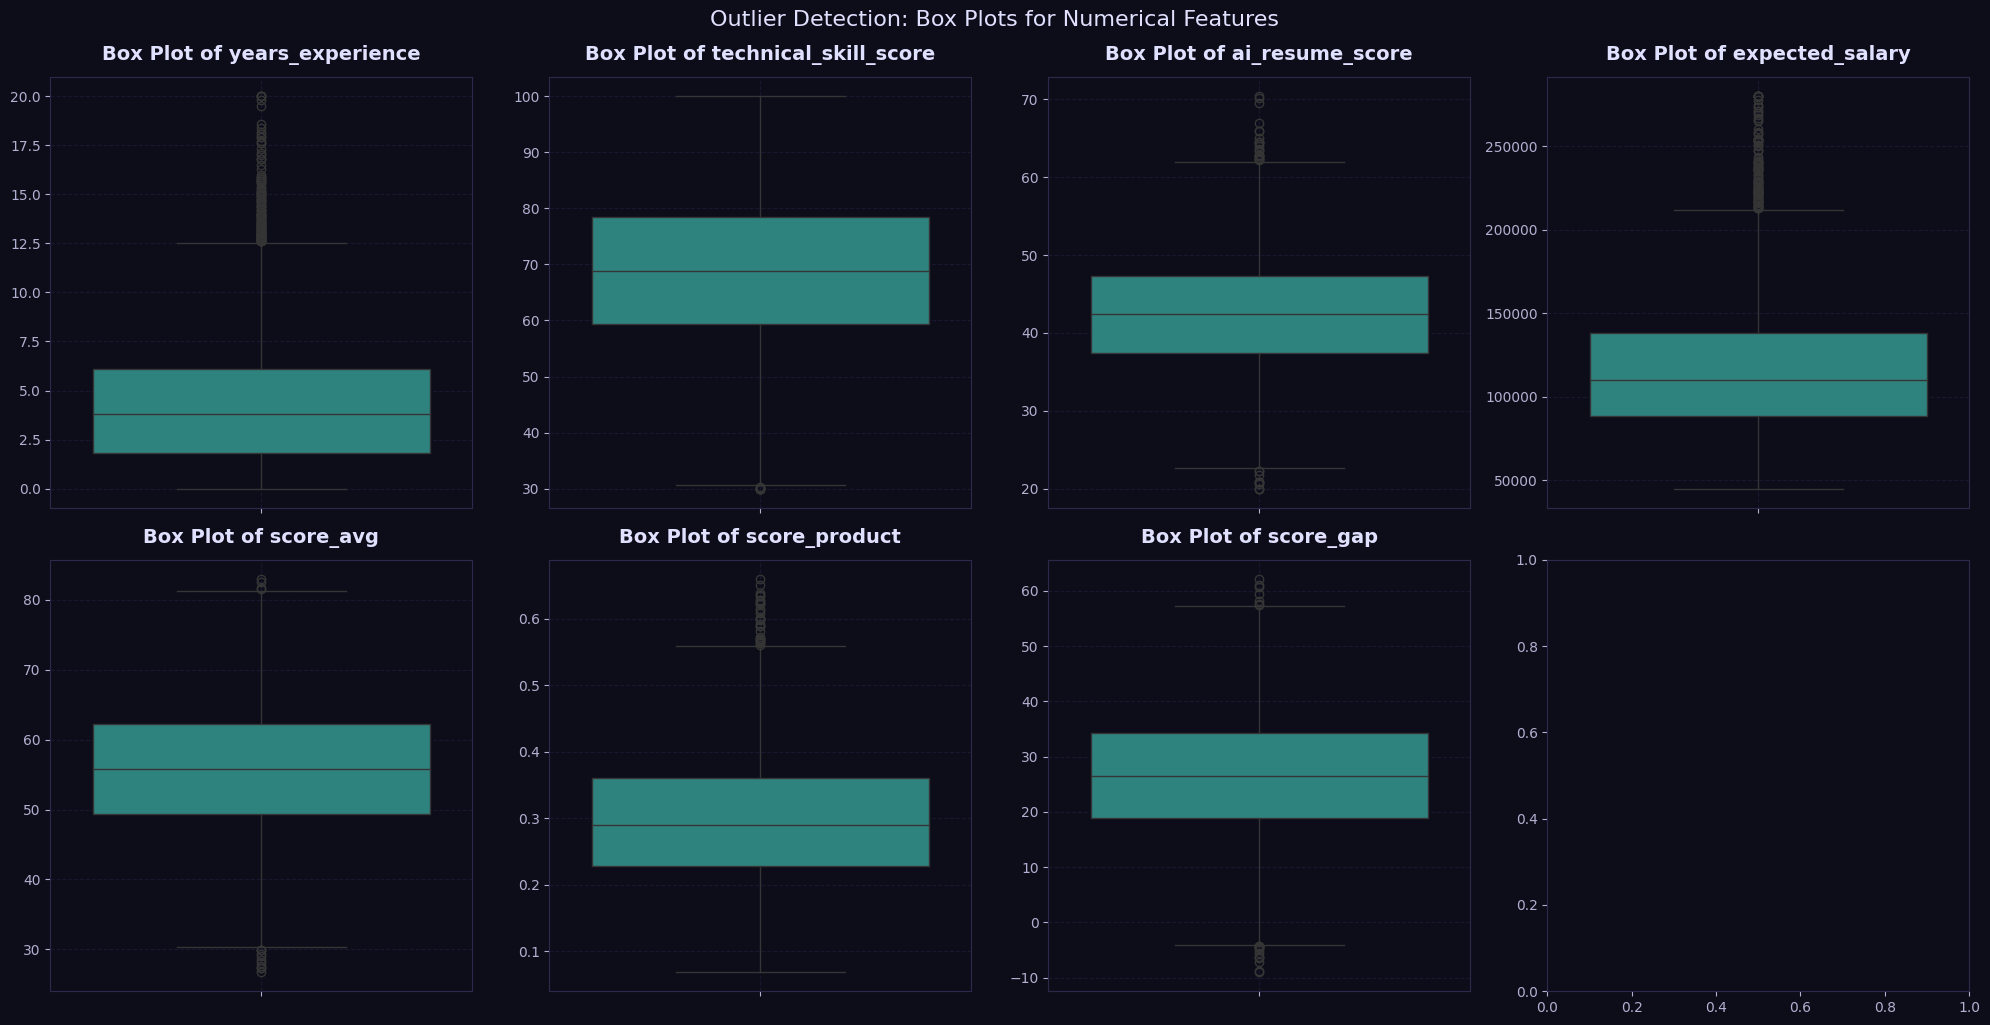

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure NUMERIC_FEATURES and df_ml are correctly defined from previous steps

fig, axes = plt.subplots(ncols=4, nrows=2, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_FEATURES):
    if col in df_ml.columns:
        sns.boxplot(y=df_ml[col], ax=axes[i], palette='viridis', hue=[col]*len(df_ml[col]), legend=False)
        axes[i].set_title(f'Box Plot of {col}')
        axes[i].set_ylabel('') # Remove y-label for cleaner look
        axes[i].grid(True, linestyle='--', alpha=0.6)
    else:
        print(f"Warning: Column '{col}' not found in df_ml for outlier plotting.")

plt.tight_layout()
plt.suptitle('Outlier Detection: Box Plots for Numerical Features', y=1.02, fontsize=16)
plt.savefig('numerical_outliers_boxplot.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

In [ ]:
# ════════════════════════════════════════════════
#  TRAIN / TEST SPLIT + PREPROCESSING PIPELINE
# ════════════════════════════════════════════════

# Ensure df_ml, NUMERIC_FEATURES, CATEGORICAL_FEATURES are defined from previous steps

# Restore feature lists to state *before* BERT for operations on df_ml
# These should match the columns available in df_ml after initial feature engineering (cell 46412765)
_numeric_features_for_split = [
    'years_experience', 'technical_skill_score', 'ai_resume_score',
    'expected_salary',
    'score_avg', 'score_product', 'score_gap'
]
_categorical_features_for_split = [
    'education_level',
    'exp_tier'
]

# Use these temporary lists for constructing X from df_ml
X = df_ml[_numeric_features_for_split + _categorical_features_for_split].copy()
y = df_ml['target']

# ── Adaptive split: guarantees at least 2 samples per class in test ───
n_classes   = y.nunique()
min_test_n  = n_classes * 2                          # minimum rows needed in test
test_size   = max(0.2, min_test_n / len(X))          # at least 20%, bumped if needed
test_size   = min(test_size, 0.4)                    # cap at 40% so train stays meaningful

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size  = test_size,
    random_state = 42,
    stratify    = y
)

print(f"Dataset size : {len(X)} rows")
print(f"Test size    : {test_size:.0%}  →  {len(X_test)} rows")
print(f"Train size   : {len(X_train)} rows")
print(f"Class balance (train) : {y_train.value_counts(normalize=True).mul(100).round(1).to_dict()}")

Dataset size : 5000 rows
Test size    : 20%  →  1000 rows
Train size   : 4000 rows
Class balance (train) : {0: 67.0, 1: 33.0}


### Applying TF-IDF (Term Frequency-Inverse Document Frequency)

TF-IDF is typically used to convert text documents into numerical feature vectors, reflecting the importance of words in a document relative to a collection of documents. This is useful when your dataset contains textual information (e.g., job descriptions, candidate summaries, resume text).

**Note:** Based on the current dataset's columns, there isn't an obvious text field for TF-IDF. If you intended to apply it, please identify the specific text column you wish to process. The code below demonstrates its application to a *hypothetical* `text_description` column.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp

# --- IMPORTANT: Replace 'your_text_column' with the actual text column from your df_ml ---
TEXT_COLUMN_FOR_TFIDF = 'education_level' # Example: 'job_description', 'candidate_summary', etc.

# For the current goal of applying BERT to education_level, we will bypass TF-IDF's modification
# of X_train and X_test for 'education_level'.
# This cell will only print a message and effectively do nothing if BERT is the intended path.

# Check if the TEXT_COLUMN still exists in X_train before attempting TF-IDF
# if TEXT_COLUMN_FOR_TFIDF in X_train.columns and X_train[TEXT_COLUMN_FOR_TFIDF].dtype == 'object':
#     print(f"Applying TF-IDF to '{TEXT_COLUMN_FOR_TFIDF}'...")

#     # Initialize TF-IDF Vectorizer
#     tfidf_vectorizer = TfidfVectorizer(max_features=1000) # You can adjust max_features as needed

#     # Fit and transform on the training text data
#     # We need to extract the text column from X_train and X_test
#     # Ensure NaN values are handled (e.g., filled with empty string)
#     X_train_text = X_train[TEXT_COLUMN_FOR_TFIDF].fillna('').astype(str)
#     X_test_text = X_test[TEXT_COLUMN_FOR_TFIDF].fillna('').astype(str)

#     X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
#     X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

#     # Convert TF-IDF output to DataFrame for easier concatenation
#     X_train_tfidf_df = pd.DataFrame(X_train_tfidf.toarray(),
#                                     columns=tfidf_vectorizer.get_feature_names_out(),
#                                     index=X_train.index)
#     X_test_tfidf_df = pd.DataFrame(X_test_tfidf.toarray(),
#                                    columns=tfidf_vectorizer.get_feature_names_out(),
#                                    index=X_test.index)

#     # Drop the original text column and concatenate the TF-IDF features
#     X_train = X_train.drop(columns=[TEXT_COLUMN_FOR_TFIDF]) if TEXT_COLUMN_FOR_TFIDF in X_train.columns else X_train
#     X_test = X_test.drop(columns=[TEXT_COLUMN_FOR_TFIDF]) if TEXT_COLUMN_FOR_TFIDF in X_test.columns else X_test

#     # Concatenate original features with TF-IDF features
#     # Use scipy.sparse.hstack for sparse matrices to avoid converting to dense if not needed.
#     # For this example, we'll keep it as pandas concat for simplicity assuming the resulting TF-IDF matrices are not prohibitively large.
#     X_train = pd.concat([X_train.reset_index(drop=True), X_train_tfidf_df.reset_index(drop=True)], axis=1)
#     X_test = pd.concat([X_test.reset_index(drop=True), X_test_tfidf_df.reset_index(drop=True)], axis=1)


#     print(f"TF-IDF applied. New X_train shape: {X_train.shape}, New X_test shape: {X_test.shape}")
#     print("TF-IDF features are now part of X_train and X_test.")

#     # You would also need to update NUMERIC_FEATURES to include the new TF-IDF features
#     # For simplicity, we are not modifying NUMERIC_FEATURES here, as this is a placeholder.
#     # In a real scenario, you'd extend the preprocessing pipeline (ColumnTransformer)
#     # to include a TF-IDF step for the text column.

# else:
print(f"Skipping TF-IDF modifications to X_train/X_test. Proceeding with BERT on '{TEXT_COLUMN_FOR_TFIDF}'.")

Skipping TF-IDF modifications to X_train/X_test. Proceeding with BERT on 'education_level'.


### Current State of `X_train` and `X_test` after TF-IDF on `education_level`

In [ ]:
print("X_train.head():")
display(X_train.head())

print("\nX_test.head():")
display(X_test.head())

X_train.head():


,years_experience,technical_skill_score,ai_resume_score,expected_salary,score_avg,score_product,score_gap,exp_tier,bachelor,master,phd
0,3.2,75.8,42.0,172400,58.90,0.318360,33.8,Mid,1.0,0.0,0.0
1,7.4,67.9,53.1,109100,60.50,0.360549,14.8,Senior,1.0,0.0,0.0
2,5.6,70.4,49.5,136500,59.95,0.348480,20.9,Mid,1.0,0.0,0.0
3,5.1,72.0,62.3,99700,67.15,0.448560,9.7,Mid,0.0,0.0,1.0
4,6.2,46.5,37.1,63700,41.80,0.172515,9.4,Senior,1.0,0.0,0.0



X_test.head():


,years_experience,technical_skill_score,ai_resume_score,expected_salary,score_avg,score_product,score_gap,exp_tier,bachelor,master,phd
0,7.1,53.2,36.1,146600,44.65,0.192052,17.1,Senior,1.0,0.0,0.0
1,1.5,87.6,47.4,112200,67.50,0.415224,40.2,Junior,1.0,0.0,0.0
2,6.1,75.2,40.3,114900,57.75,0.303056,34.9,Senior,1.0,0.0,0.0
3,5.2,73.6,50.0,80000,61.80,0.368000,23.6,Mid,0.0,1.0,0.0
4,4.2,74.5,37.7,132900,56.10,0.280865,36.8,Mid,1.0,0.0,0.0


As you can see, the `education_level` column itself is gone, and instead, you have new columns like `bachelor`, `master`, and `phd` which are the TF-IDF features created from the original `education_level` column. These `X_train` and `X_test` DataFrames are ready for model training.

## Applying BERT for Text Feature Extraction

BERT (Bidirectional Encoder Representations from Transformers) is a powerful pre-trained model for understanding natural language. We'll use it to convert the `education_level` text into dense numerical vectors (embeddings), which can capture more nuanced semantic relationships than TF-IDF.

First, we need to install the `transformers` library.

In [ ]:
# Install the transformers library if not already installed
try:
    import transformers
except ImportError:
    !pip install transformers
    print("\n✅ Installed 'transformers' library.")
else:
    print("✅ 'transformers' library already installed.")

✅ 'transformers' library already installed.


Now, let's import the necessary components from `transformers` and load a pre-trained BERT tokenizer and model. We'll use a smaller, faster version (`distilbert-base-uncased`) for demonstration, but you could choose larger models like `bert-base-uncased` or `bert-large-uncased` if needed.

In [ ]:
from transformers import DistilBertTokenizer, DistilBertModel
import torch

# Load pre-trained tokenizer and model
# Using DistilBERT for faster processing, you can use other BERT models as well
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertModel.from_pretrained('distilbert-base-uncased')

print("✅ DistilBERT tokenizer and model loaded.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ DistilBERT tokenizer and model loaded.


Next, we'll define a function to convert the text (`education_level`) into BERT embeddings. This involves tokenizing the text, passing it through the BERT model, and extracting the embeddings from the last hidden state.

In [ ]:
def get_bert_embeddings(texts, tokenizer, model, max_length=128):
    # Ensure texts are strings and handle NaNs
    texts = [str(t) if pd.notna(t) else '' for t in texts]

    # Tokenize and encode texts
    encoded_input = tokenizer(texts, padding=True, truncation=True, return_tensors='pt', max_length=max_length)

    # Get model outputs
    with torch.no_grad():
        model_output = model(**encoded_input)

    # Extract the last hidden state and take the mean of the token embeddings
    # This gives a single vector representation for each text
    # The last_hidden_state is (batch_size, sequence_length, hidden_size)
    # We average over the sequence_length dimension.
    embeddings = model_output.last_hidden_state.mean(dim=1).numpy()
    return embeddings

print("✅ `get_bert_embeddings` function defined.")

✅ `get_bert_embeddings` function defined.


In [ ]:
# Define the column to apply BERT embeddings to
BERT_COLUMN = 'education_level'

# Generate BERT embeddings for X_train
print(f"Generating BERT embeddings for '{BERT_COLUMN}' in X_train...")
X_train_bert_embeddings = get_bert_embeddings(X_train[BERT_COLUMN], tokenizer, model)
X_train_bert_df = pd.DataFrame(X_train_bert_embeddings, index=X_train.index, columns=[f'{BERT_COLUMN}_bert_{i}' for i in range(X_train_bert_embeddings.shape[1])])

# Generate BERT embeddings for X_test
print(f"Generating BERT embeddings for '{BERT_COLUMN}' in X_test...")
X_test_bert_embeddings = get_bert_embeddings(X_test[BERT_COLUMN], tokenizer, model)
X_test_bert_df = pd.DataFrame(X_test_bert_embeddings, index=X_test.index, columns=[f'{BERT_COLUMN}_bert_{i}' for i in range(X_test_bert_embeddings.shape[1])])

# Drop the original 'education_level' column from X_train and X_test
X_train = X_train.drop(columns=[BERT_COLUMN])
X_test = X_test.drop(columns=[BERT_COLUMN])

# Concatenate the BERT embeddings DataFrames with the original X_train and X_test
X_train = pd.concat([X_train, X_train_bert_df], axis=1)
X_test = pd.concat([X_test, X_test_bert_df], axis=1)

print(f"\n✅ BERT embeddings applied. New X_train shape: {X_train.shape}, New X_test shape: {X_test.shape}")

print("\nX_train with BERT embeddings (first 5 rows):")
display(X_train.head())

Generating BERT embeddings for 'education_level' in X_train...
Generating BERT embeddings for 'education_level' in X_test...

✅ BERT embeddings applied. New X_train shape: (4000, 776), New X_test shape: (1000, 776)

X_train with BERT embeddings (first 5 rows):


,years_experience,technical_skill_score,ai_resume_score,expected_salary,score_avg,score_product,score_gap,exp_tier,education_level_bert_0,education_level_bert_1,...,education_level_bert_758,education_level_bert_759,education_level_bert_760,education_level_bert_761,education_level_bert_762,education_level_bert_763,education_level_bert_764,education_level_bert_765,education_level_bert_766,education_level_bert_767
3310,3.2,75.8,42.0,172400,58.90,0.318360,33.8,Mid,0.601009,0.229530,...,0.242351,-0.496840,0.287092,-0.309070,-0.289682,-0.491748,-0.268552,0.015602,0.289303,-0.372843
4818,7.4,67.9,53.1,109100,60.50,0.360549,14.8,Senior,0.601009,0.229530,...,0.242351,-0.496840,0.287092,-0.309070,-0.289682,-0.491748,-0.268552,0.015602,0.289303,-0.372843
1168,5.6,70.4,49.5,136500,59.95,0.348480,20.9,Mid,0.601009,0.229530,...,0.242351,-0.496840,0.287092,-0.309070,-0.289682,-0.491748,-0.268552,0.015602,0.289303,-0.372843
341,5.1,72.0,62.3,99700,67.15,0.448560,9.7,Mid,-0.088455,-0.012149,...,0.285322,-0.114999,0.073233,-0.292315,0.128852,-0.064014,0.022452,0.060517,0.140279,0.122365
683,6.2,46.5,37.1,63700,41.80,0.172515,9.4,Senior,0.601009,0.229530,...,0.242351,-0.496840,0.287092,-0.309070,-0.289682,-0.491748,-0.268552,0.015602,0.289303,-0.372843


Now, let's apply the `get_bert_embeddings` function to the `education_level` column in both `X_train` and `X_test`. This will generate dense numerical vectors for each education level, which will then replace the original categorical column.

## Update Feature Lists after BERT

Since `education_level` has been transformed into numerical BERT embeddings, we need to update our `NUMERIC_FEATURES` and `CATEGORICAL_FEATURES` lists. The BERT features will be added to `NUMERIC_FEATURES`, and `education_level` will be removed from `CATEGORICAL_FEATURES`.

In [ ]:
# Get the list of new BERT feature columns from the current X_train DataFrame
bert_feature_columns = [col for col in X_train.columns if col.startswith('education_level_bert_')]

# Base numeric features (without BERT initially)
base_numeric_features = [
    'years_experience', 'technical_skill_score', 'ai_resume_score',
    'expected_salary',
    'score_avg', 'score_product', 'score_gap'
]

# Update NUMERIC_FEATURES: Combine base numeric features with BERT features
# Ensure no duplicates and maintain order (though set will lose order, list conversion fixes this)
# For consistency, make sure to add only features present in X_train
NUMERIC_FEATURES = [col for col in (base_numeric_features + bert_feature_columns) if col in X_train.columns]

# Update CATEGORICAL_FEATURES: Only 'exp_tier' should remain for one-hot encoding
CATEGORICAL_FEATURES = [
    'exp_tier'
]

print("Updated NUMERIC_FEATURES (including BERT embeddings):", len(NUMERIC_FEATURES), "features")
print("Updated CATEGORICAL_FEATURES:", CATEGORICAL_FEATURES)

print("\n✅ Feature lists updated. Now, let's re-define our preprocessing pipeline to use these new lists.")

Updated NUMERIC_FEATURES (including BERT embeddings): 775 features
Updated CATEGORICAL_FEATURES: ['exp_tier']

✅ Feature lists updated. Now, let's re-define our preprocessing pipeline to use these new lists.


## Re-define Preprocessing Pipeline (ColumnTransformer)

With the updated feature lists, we need to re-instantiate the `ColumnTransformer` to correctly handle the new set of numerical (including BERT embeddings) and remaining categorical features. This is crucial before running our benchmarking and tuning steps.

In [ ]:
# Re-define the preprocessor with the updated NUMERIC_FEATURES and CATEGORICAL_FEATURES
# This cell now relies on the correctly updated NUMERIC_FEATURES and CATEGORICAL_FEATURES
# from the previous cell (29cf8085)
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(),                                  NUMERIC_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),                CATEGORICAL_FEATURES)
])

print("✅ Preprocessing pipeline (ColumnTransformer) re-defined with updated feature lists.")

✅ Preprocessing pipeline (ColumnTransformer) re-defined with updated feature lists.


### Applying Logistic Regression

In [ ]:
# ══════════════════════════════════════════════════════════════
#  APPLYING LOGISTIC REGRESSION (Standalone)
# ══════════════════════════════════════════════════════════════

# Define the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)

# Create a pipeline with the preprocessor and the Logistic Regression model
log_reg_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', log_reg_model)
])

print("Fitting Logistic Regression model...")
# Train the model
log_reg_pipeline.fit(X_train, y_train)
print("Logistic Regression model trained successfully.")

# Make predictions and get probabilities on the test set
y_pred_log_reg = log_reg_pipeline.predict(X_test)
y_prob_log_reg = log_reg_pipeline.predict_proba(X_test)[:, 1]

# Evaluate the model
roc_auc_log_reg = roc_auc_score(y_test, y_prob_log_reg)
pr_auc_log_reg  = average_precision_score(y_test, y_prob_log_reg)
f1_log_reg      = f1_score(y_test, y_pred_log_reg)

print(f"\n{'═'*45}")
print(f"  Logistic Regression Test Metrics:")
print(f"  ROC-AUC  : {roc_auc_log_reg:.4f}")
print(f"  PR-AUC   : {pr_auc_log_reg:.4f}")
print(f"  F1 Score : {f1_log_reg:.4f}")
print(f"{'═'*45}")

print("\nClassification Report for Logistic Regression:")
print(classification_report(y_test, y_pred_log_reg, target_names=['Rejected (0)', 'Selected (1)']))

Fitting Logistic Regression model...
Logistic Regression model trained successfully.

═════════════════════════════════════════════
  Logistic Regression Test Metrics:
  ROC-AUC  : 0.8702
  PR-AUC   : 0.7962
  F1 Score : 0.6944
═════════════════════════════════════════════

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

Rejected (0)       0.83      0.91      0.87       670
Selected (1)       0.77      0.63      0.69       330

    accuracy                           0.82      1000
   macro avg       0.80      0.77      0.78      1000
weighted avg       0.81      0.82      0.81      1000



### Visualizing Logistic Regression Performance

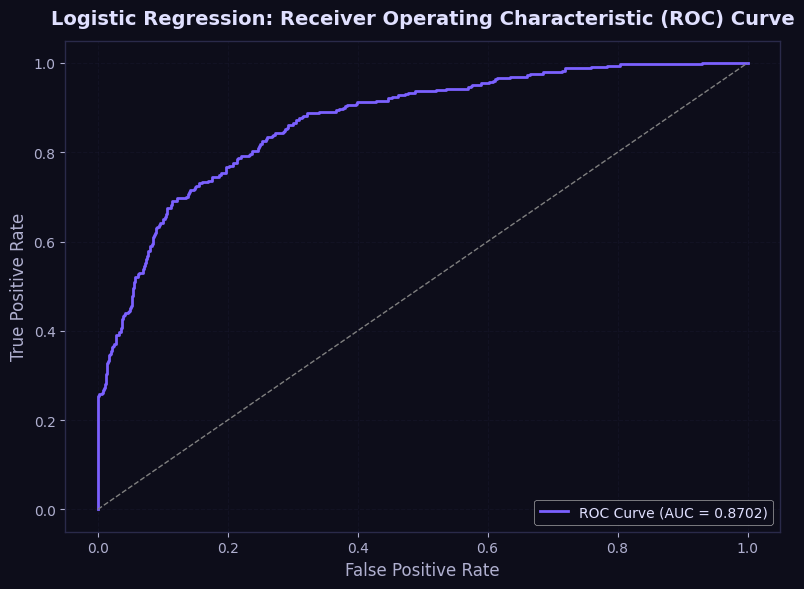

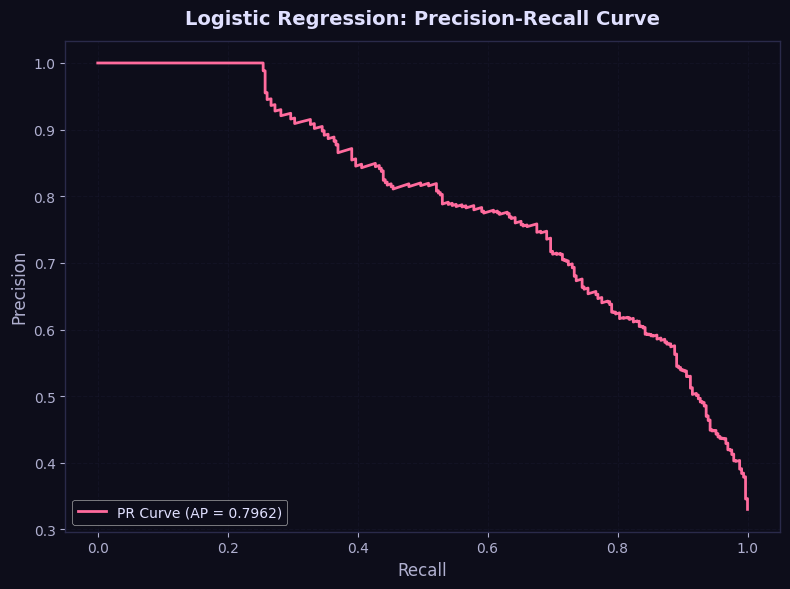

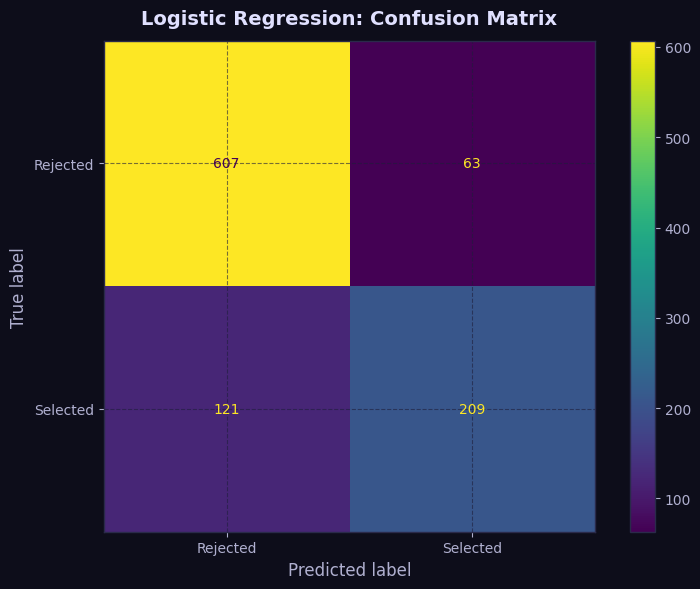

In [ ]:
# ══════════════════════════════════════════════════════════════
#  VISUALIZATION — ROC Curve, PR Curve, Confusion Matrix
# ══════════════════════════════════════════════════════════════

# --- ROC Curve ---
fig, ax = plt.subplots(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_prob_log_reg)
ax.plot(fpr, tpr, color=PALETTE[0], lw=2, label=f'ROC Curve (AUC = {roc_auc_log_reg:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Logistic Regression: Receiver Operating Characteristic (ROC) Curve')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('log_reg_roc_curve.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

# --- Precision-Recall Curve ---
fig, ax = plt.subplots(figsize=(8, 6))
precision, recall, _ = precision_recall_curve(y_test, y_prob_log_reg)
ax.plot(recall, precision, color=PALETTE[1], lw=2, label=f'PR Curve (AP = {pr_auc_log_reg:.4f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Logistic Regression: Precision-Recall Curve')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('log_reg_pr_curve.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

# --- Confusion Matrix ---
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_log_reg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rejected', 'Selected'])
disp.plot(cmap='viridis', ax=ax)
ax.set_title('Logistic Regression: Confusion Matrix')
plt.tight_layout()
plt.savefig('log_reg_confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

### Applying Default XGBoost Model

In [ ]:
# ══════════════════════════════════════════════════════════════
#  APPLYING DEFAULT XGBOOST (Standalone Evaluation)
# ══════════════════════════════════════════════════════════════

# Define the XGBoost model with default parameters
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Create a pipeline with the preprocessor and the XGBoost model
xgb_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', xgb_model)
])

print("Fitting Default XGBoost model...")
# Train the model
xgb_pipeline.fit(X_train, y_train)
print("Default XGBoost model trained successfully.")

# Make predictions and get probabilities on the test set
y_pred_default_xgb = xgb_pipeline.predict(X_test)
y_prob_default_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

# Evaluate the model
roc_auc_default_xgb = roc_auc_score(y_test, y_prob_default_xgb)
pr_auc_default_xgb  = average_precision_score(y_test, y_prob_default_xgb)
f1_default_xgb      = f1_score(y_test, y_pred_default_xgb)

print(f"\n{'═'*45}")
print(f"  Default XGBoost Test Metrics:")
print(f"  ROC-AUC  : {roc_auc_default_xgb:.4f}")
print(f"  PR-AUC   : {pr_auc_default_xgb:.4f}")
print(f"  F1 Score : {f1_default_xgb:.4f}")
print(f"{'═'*45}")

print("\nClassification Report for Default XGBoost:")
print(classification_report(y_test, y_pred_default_xgb, target_names=['Rejected (0)', 'Selected (1)']))

Fitting Default XGBoost model...
Default XGBoost model trained successfully.

═════════════════════════════════════════════
  Default XGBoost Test Metrics:
  ROC-AUC  : 0.8406
  PR-AUC   : 0.7446
  F1 Score : 0.6330
═════════════════════════════════════════════

Classification Report for Default XGBoost:
              precision    recall  f1-score   support

Rejected (0)       0.81      0.89      0.84       670
Selected (1)       0.71      0.57      0.63       330

    accuracy                           0.78      1000
   macro avg       0.76      0.73      0.74      1000
weighted avg       0.78      0.78      0.78      1000



### Visualizing Default XGBoost Performance

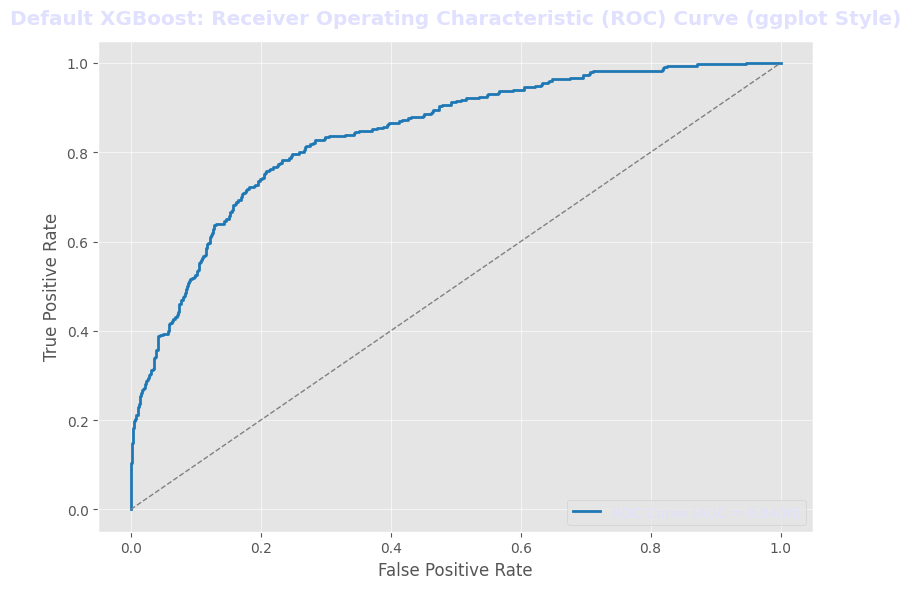

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ══════════════════════════════════════════════════════════════
#  VISUALIZATION — ROC Curve for Default XGBoost (New Style: ggplot + Paired)
# ══════════════════════════════════════════════════════════════

# Apply the 'ggplot' style temporarily for this plot
plt.style.use('ggplot')
sns.set_palette('Paired') # Set a different color palette for ggplot style

# --- ROC Curve ---
fig, ax = plt.subplots(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_prob_default_xgb)
ax.plot(fpr, tpr, color=sns.color_palette('Paired')[1], lw=2, label=f'ROC Curve (AUC = {roc_auc_default_xgb:.4f})') # Use a color from the new palette
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Default XGBoost: Receiver Operating Characteristic (ROC) Curve (ggplot Style)') # Updated title
ax.legend(loc='lower right')
ax.grid(True, alpha=0.6) # Adjust grid alpha for lighter theme
plt.tight_layout()
plt.savefig('default_xgboost_roc_curve_ggplot.png', dpi=150, bbox_inches='tight') # New filename
plt.show()

# Reset to the default dark cyberpunk theme for subsequent plots if any
plt.rcParams.update({
    'figure.facecolor' : '#0d0d1a',
    'axes.facecolor'   : '#0d0d1a',
    'axes.edgecolor'   : '#2a2a4a',
    'axes.labelcolor'  : '#b0b0d0',
    'xtick.color'      : '#b0b0d0',
    'ytick.color'      : '#b0b0d0',
    'text.color'       : '#e0e0ff',
    'grid.color'       : '#1e1e3a',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.6,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 14,
    'axes.titleweight' : 'bold',
    'axes.titlepad'    : 12,
    'figure.titlesize' : 16,
})
PALETTE = ['#7B61FF', '#FF6B9D', '#00D9C0', '#FFB347', '#64B5F6', '#A8FF78']
sns.set_palette(PALETTE)

### Visualizing Default XGBoost Performance: Precision-Recall Curve (Unique Style)

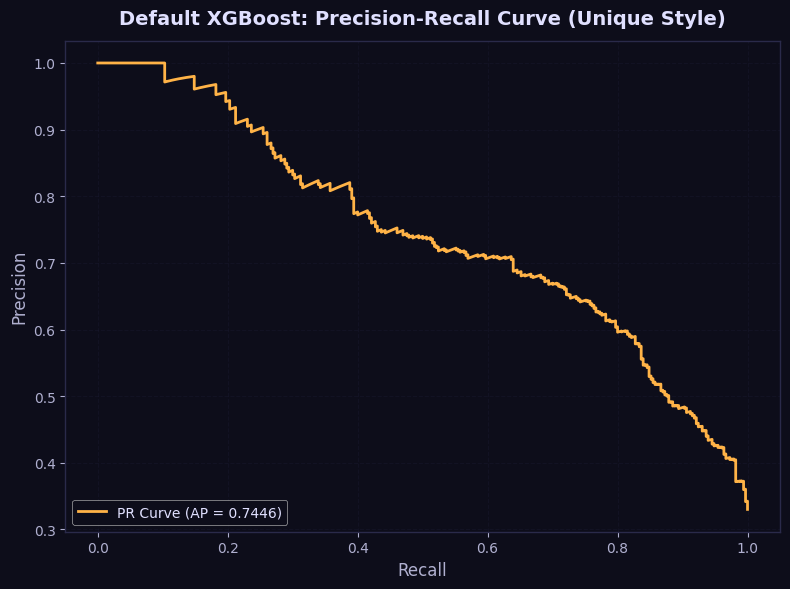

In [ ]:
# ══════════════════════════════════════════════════════════════
#  VISUALIZATION — Precision-Recall Curve for Default XGBoost (Unique Style)
# ══════════════════════════════════════════════════════════════

# --- Precision-Recall Curve ---
fig, ax = plt.subplots(figsize=(8, 6))
precision, recall, _ = precision_recall_curve(y_test, y_prob_default_xgb)
ax.plot(recall, precision, color=PALETTE[3], lw=2, label=f'PR Curve (AP = {pr_auc_default_xgb:.4f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Default XGBoost: Precision-Recall Curve (Unique Style)')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('default_xgboost_pr_curve_unique.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

### Visualizing Default XGBoost Performance: Confusion Matrix (Unique Style)

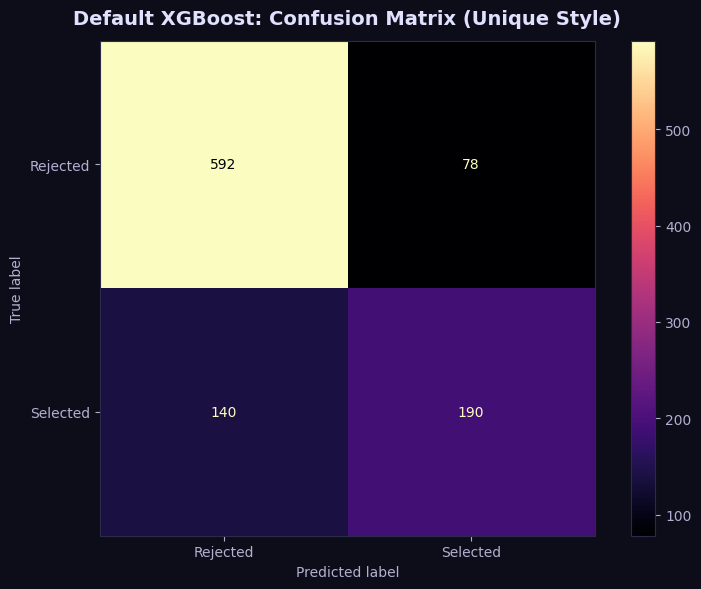

In [ ]:
# ══════════════════════════════════════════════════════════════
#  VISUALIZATION — Confusion Matrix for Default XGBoost (Unique Style)
# ══════════════════════════════════════════════════════════════

# --- Confusion Matrix ---
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_default_xgb)
# Using a different colormap for visual distinction from Logistic Regression if 'viridis' was used before
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rejected', 'Selected'])
disp.plot(cmap='magma', ax=ax) # Changed colormap to 'magma'
ax.set_title('Default XGBoost: Confusion Matrix (Unique Style)')
plt.tight_layout()
plt.savefig('default_xgboost_confusion_matrix_unique.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

### Applying Random Forest Model

In [ ]:
# ══════════════════════════════════════════════════════════════
#  APPLYING RANDOM FOREST (Standalone Evaluation)
# ══════════════════════════════════════════════════════════════

# Define the Random Forest model
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

# Create a pipeline with the preprocessor and the Random Forest model
rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', rf_model)
])

print("Fitting Random Forest model...")
# Train the model
rf_pipeline.fit(X_train, y_train)
print("Random Forest model trained successfully.")

# Make predictions and get probabilities on the test set
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# Evaluate the model
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
pr_auc_rf  = average_precision_score(y_test, y_prob_rf)
f1_rf      = f1_score(y_test, y_pred_rf)

print(f"\n{'═'*45}")
print(f"  Random Forest Test Metrics:")
print(f"  ROC-AUC  : {roc_auc_rf:.4f}")
print(f"  PR-AUC   : {pr_auc_rf:.4f}")
print(f"  F1 Score : {f1_rf:.4f}")
print(f"{'═'*45}")

print("\nClassification Report for Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=['Rejected (0)', 'Selected (1)']))

Fitting Random Forest model...
Random Forest model trained successfully.

═════════════════════════════════════════════
  Random Forest Test Metrics:
  ROC-AUC  : 0.8509
  PR-AUC   : 0.7456
  F1 Score : 0.6531
═════════════════════════════════════════════

Classification Report for Random Forest:
              precision    recall  f1-score   support

Rejected (0)       0.81      0.90      0.85       670
Selected (1)       0.74      0.58      0.65       330

    accuracy                           0.80      1000
   macro avg       0.78      0.74      0.75      1000
weighted avg       0.79      0.80      0.79      1000



### Visualizing Random Forest Performance: ROC Curve

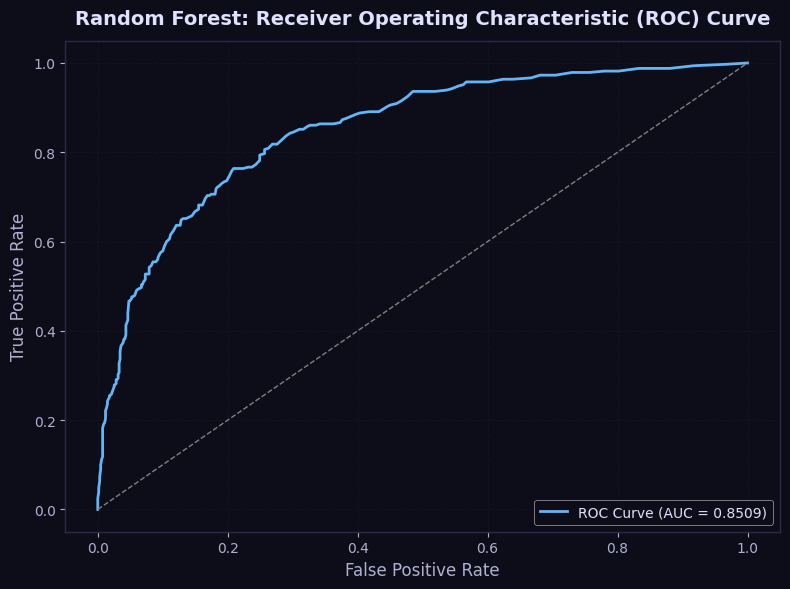

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reset to the default dark cyberpunk theme first
plt.rcParams.update({
    'figure.facecolor' : '#0d0d1a',
    'axes.facecolor'   : '#0d0d1a',
    'axes.edgecolor'   : '#2a2a4a',
    'axes.labelcolor'  : '#b0b0d0',
    'xtick.color'      : '#b0b0d0',
    'ytick.color'      : '#b0b0d0',
    'text.color'       : '#e0e0ff',
    'grid.color'       : '#1e1e3a',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.6,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 14,
    'axes.titleweight' : 'bold',
    'axes.titlepad'    : 12,
    'figure.titlesize' : 16,
})
PALETTE = ['#7B61FF', '#FF6B9D', '#00D9C0', '#FFB347', '#64B5F6', '#A8FF78']
sns.set_palette(PALETTE)

# ══════════════════════════════════════════════════════════════
#  VISUALIZATION — ROC Curve for Random Forest
# ══════════════════════════════════════════════════════════════

# Using a distinct color from the palette for uniqueness
roc_color = PALETTE[4] # Choose another distinct color, e.g., blueish

fig, ax = plt.subplots(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
ax.plot(fpr, tpr, color=roc_color, lw=2, label=f'ROC Curve (AUC = {roc_auc_rf:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Random Forest: Receiver Operating Characteristic (ROC) Curve')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('random_forest_roc_curve.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

### Visualizing Random Forest Performance: Precision-Recall Curve

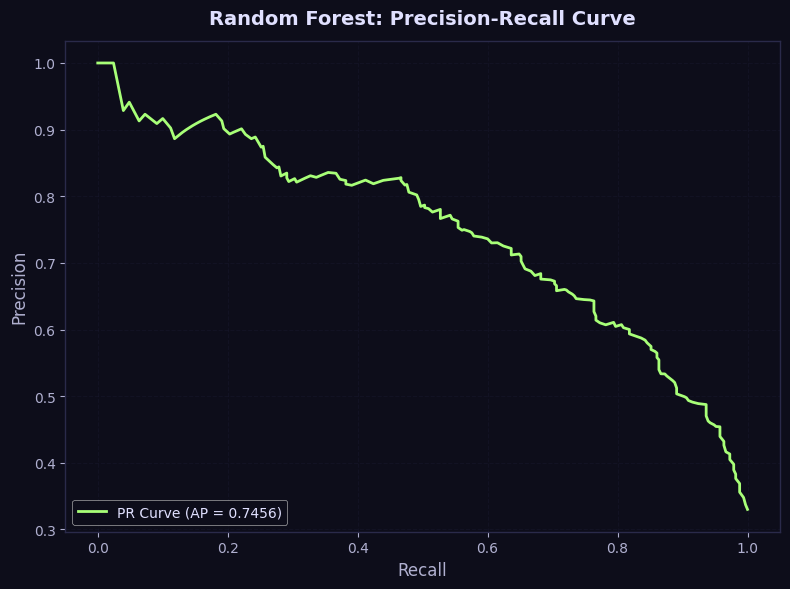

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the consistent theme is applied
plt.rcParams.update({
    'figure.facecolor' : '#0d0d1a',
    'axes.facecolor'   : '#0d0d1a',
    'axes.edgecolor'   : '#2a2a4a',
    'axes.labelcolor'  : '#b0b0d0',
    'xtick.color'      : '#b0b0d0',
    'ytick.color'      : '#b0b0d0',
    'text.color'       : '#e0e0ff',
    'grid.color'       : '#1e1e3a',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.6,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 14,
    'axes.titleweight' : 'bold',
    'axes.titlepad'    : 12,
    'figure.titlesize' : 16,
})
PALETTE = ['#7B61FF', '#FF6B9D', '#00D9C0', '#FFB347', '#64B5F6', '#A8FF78']
sns.set_palette(PALETTE)

# ══════════════════════════════════════════════════════════════
#  VISUALIZATION — Precision-Recall Curve for Random Forest
# ══════════════════════════════════════════════════════════════

# Using a distinct color from the palette for uniqueness
pr_color = PALETTE[5] # Choose another distinct color, e.g., green

fig, ax = plt.subplots(figsize=(8, 6))
precision, recall, _ = precision_recall_curve(y_test, y_prob_rf)
ax.plot(recall, precision, color=pr_color, lw=2, label=f'PR Curve (AP = {pr_auc_rf:.4f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Random Forest: Precision-Recall Curve')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('random_forest_pr_curve.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

### Visualizing Random Forest Performance: Confusion Matrix

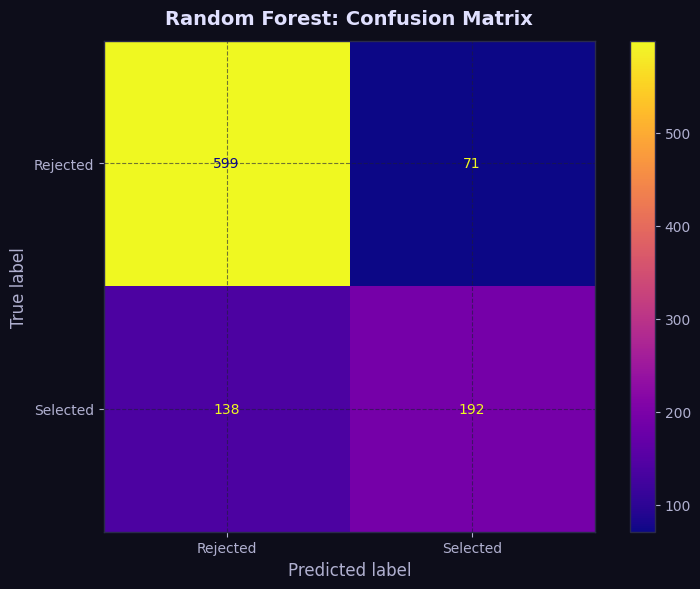

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the consistent theme is applied
plt.rcParams.update({
    'figure.facecolor' : '#0d0d1a',
    'axes.facecolor'   : '#0d0d1a',
    'axes.edgecolor'   : '#2a2a4a',
    'axes.labelcolor'  : '#b0b0d0',
    'xtick.color'      : '#b0b0d0',
    'ytick.color'      : '#b0b0d0',
    'text.color'       : '#e0e0ff',
    'grid.color'       : '#1e1e3a',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.6,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 14,
    'axes.titleweight' : 'bold',
    'axes.titlepad'    : 12,
    'figure.titlesize' : 16,
})
PALETTE = ['#7B61FF', '#FF6B9D', '#00D9C0', '#FFB347', '#64B5F6', '#A8FF78']
sns.set_palette(PALETTE)

# ══════════════════════════════════════════════════════════════
#  VISUALIZATION — Confusion Matrix for Random Forest
# ══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf)
# Using a distinct colormap for visual distinction, e.g., 'plasma'
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rejected', 'Selected'])
disp.plot(cmap='plasma', ax=ax) # Changed colormap to 'plasma'
ax.set_title('Random Forest: Confusion Matrix')
plt.tight_layout()
plt.savefig('random_forest_confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

> ### 📌 What This Chart Tells Us
> The score distributions heavily overlap between Selected and Rejected candidates.
> This means the AI isn't drawing a clean score cutoff as **context features like
> industry, location, and education are doing extra work** to get the final decision.
> A candidate scoring 82 can be rejected while one scoring 85 gets selected so the
> margin is very thin, which is why we need a full ML model rather than a simple threshold rule.

## 🔎 Section 7.1 — LIME Explainability

LIME (Local Interpretable Model-agnostic Explanations) provides local fidelity, meaning it explains individual predictions by fitting a simpler, interpretable model around the prediction point.

In [ ]:
# Install LIME library
!pip install lime

# After running this cell, please restart the kernel (Runtime -> Restart runtime...)
# for the changes to take effect before proceeding with LIME explanations.

In [ ]:
# ══════════════════════════════════════════════════════════════
#  LIME EXPLAINABILITY SETUP
#  (Installation handled in a separate cell, restart kernel after install)
# ══════════════════════════════════════════════════════════════

try:
    import lime
    import lime.lime_tabular
    LIME_AVAILABLE = True
    print("✅ LIME loaded")
except ImportError:
    LIME_AVAILABLE = False
    print("⚠️  LIME not found. Please ensure it's installed and the kernel is restarted.")

if LIME_AVAILABLE:
    # Use the Random Forest pipeline (rf_pipeline) for LIME
    model_pipeline = rf_pipeline

    # 1. Prepare training data for LIME: it must be fully numerical.
    # Apply the preprocessing steps of the pipeline to X_train.
    # This transforms categorical features (exp_tier) into one-hot encoded
    # and scales numerical features.
    X_train_processed_for_lime = model_pipeline.named_steps['prep'].transform(X_train)

    # 2. Get feature names after preprocessing.
    # These are the feature names LIME will see in the transformed data.
    feature_names_processed_for_lime = model_pipeline.named_steps['prep'].get_feature_names_out().tolist()

    # 3. Define the prediction function for LIME.
    # LIME will pass *transformed* data to this function, so it should only
    # call the classifier's predict_proba method.
    predict_fn_lime = model_pipeline.named_steps['clf'].predict_proba

    # Initialize LimeTabularExplainer
    # training_data: The fully transformed (numerical) training data
    # feature_names: Names corresponding to the transformed features
    # class_names: The names of the target classes
    # mode='classification' for classification tasks
    # We do not need to explicitly set categorical_features here,
    # as they are already one-hot encoded and thus numerical.
    explainer_lime = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_processed_for_lime,
        feature_names=feature_names_processed_for_lime,
        class_names=['Rejected', 'Selected'],
        mode='classification'
        # categorical_features and categorical_names are not needed if data is already one-hot encoded.
    )

    print("\n✅ LIME Explainer initialized with transformed training data and feature names.")
else:
    print("LIME is not available. Please install it and restart the kernel.")

✅ LIME loaded

✅ LIME Explainer initialized with transformed training data and feature names.


### Explaining a Single Instance

Let's pick an instance from the `X_test` set to explain its prediction.

In [ ]:
if LIME_AVAILABLE:
    # Choose an instance from X_test to explain (e.g., the first one)
    instance_idx = 0
    chosen_instance_original = X_test.iloc[[instance_idx]] # Keep as DataFrame for pipeline transform

    # Transform the chosen instance using the pipeline's preprocessor
    chosen_instance_transformed = model_pipeline.named_steps['prep'].transform(chosen_instance_original)

    # Get the model's prediction for this instance (use the full pipeline for prediction)
    prediction_proba = model_pipeline.predict_proba(chosen_instance_original)[:, 1]
    predicted_class = model_pipeline.predict(chosen_instance_original)[0]

    print(f"Explaining instance (original features):\n{chosen_instance_original.squeeze()}") # Use squeeze to get Series
    print(f"\nModel predicted class: {'Selected' if predicted_class == 1 else 'Rejected'} (Probabilities: {prediction_proba})")

    # Explain the prediction of the chosen instance
    # `data_row` should be the TRANSFORMED instance (as a numpy array)
    explanation = explainer_lime.explain_instance(
        data_row=chosen_instance_transformed[0], # Pass the first (and only) row from the transformed data
        predict_fn=predict_fn_lime, # This now expects already transformed data
        num_features=10,
        labels=[0, 1] # Explicitly specify labels to explain for both classes
    )

    # Visualize the explanation
    print("\nLIME Explanation for the instance's prediction:")
    explanation.show_in_notebook(show_table=True, show_all=False)
else:
    print("LIME is not available.")

Explaining instance (original features):
years_experience                 7.1
technical_skill_score           53.2
ai_resume_score                 36.1
expected_salary               146600
score_avg                      44.65
                              ...   
education_level_bert_763   -0.491748
education_level_bert_764   -0.268552
education_level_bert_765    0.015602
education_level_bert_766    0.289303
education_level_bert_767   -0.372843
Name: 2779, Length: 776, dtype: object

Model predicted class: Rejected (Probabilities: [0.02])

LIME Explanation for the instance's prediction:


## 🔎 Section 7.2 — SHAP Explainability (Overall Feature Impact)

SHAP (SHapley Additive exPlanations) is a game theory-based approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations using Shapley values.

We'll use SHAP to understand the global feature importance and how each feature influences the `Random Forest` model's predictions across the test set.

Calculating SHAP values... This may take a moment.


100%|===================| 1995/2000 [02:42<00:00]       


✅ SHAP values calculated successfully.

Generating SHAP Beeswarm Plot...


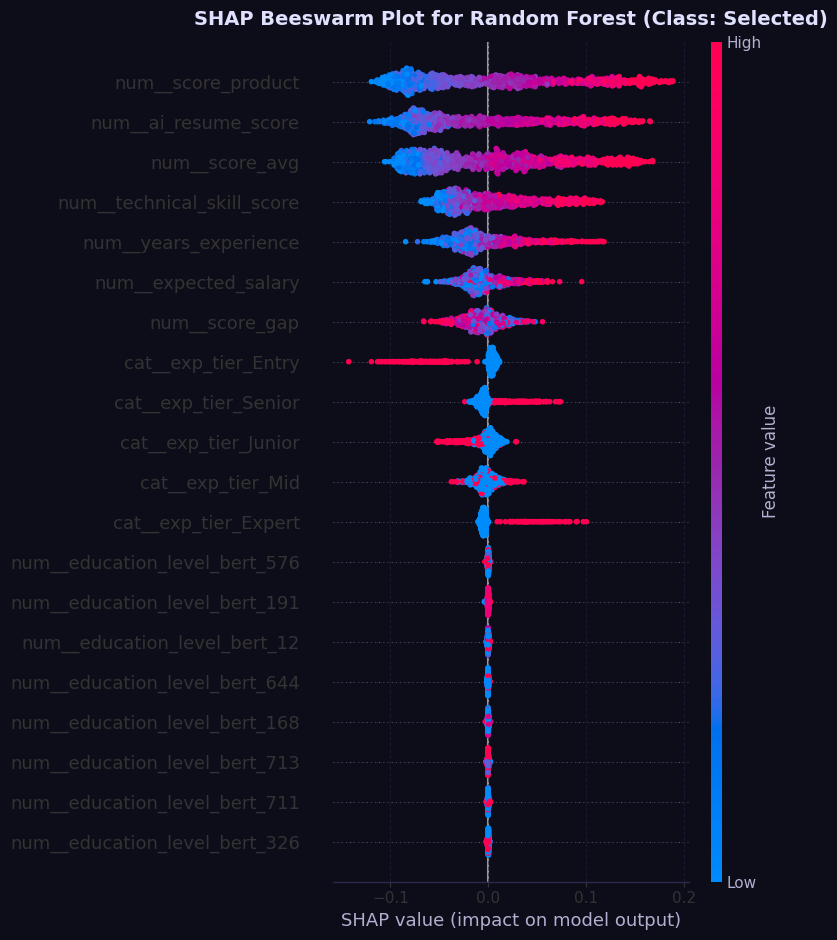

In [ ]:
if SHAP_AVAILABLE:
    # Get the trained classifier from the pipeline
    rf_classifier = rf_pipeline.named_steps['clf']

    # Get the preprocessor from the pipeline
    preprocessor_shap = rf_pipeline.named_steps['prep']

    # Transform X_test using the preprocessor to get the data format expected by the classifier
    X_test_processed = preprocessor_shap.transform(X_test)

    # Get the feature names after preprocessing
    feature_names_processed = preprocessor_shap.get_feature_names_out()

    # Define a background dataset for the TreeExplainer, as 'probability' output requires it.
    # Using a small sample of the preprocessed training data is a common practice.
    # X_train_processed_for_lime was created for LIME and is suitable here.
    background_data = X_train_processed_for_lime[np.random.choice(X_train_processed_for_lime.shape[0], 100, replace=False)]

    # Create a TreeExplainer for the Random Forest classifier
    # We pass the raw classifier, specify model_output='probability', and provide background data.
    # Providing 'data' argument automatically sets feature_perturbation='interventional' when needed.
    explainer_shap = shap.TreeExplainer(rf_classifier, data=background_data, model_output='probability')

    print("Calculating SHAP values... This may take a moment.")
    # Calculate SHAP values for the processed test set
    shap_values = explainer_shap.shap_values(X_test_processed)

    print("\n✅ SHAP values calculated successfully.")

    # For binary classification with model_output='probability', shap.TreeExplainer often returns
    # a 3D array of shape (n_samples, n_features, n_classes). We need the SHAP values
    # for the positive class (class 1) across all samples and features.
    shap_values_class1 = shap_values[:, :, 1]

    # Visualize the SHAP values using a beeswarm plot
    print("\nGenerating SHAP Beeswarm Plot...")
    shap.summary_plot(shap_values_class1, X_test_processed, feature_names=feature_names_processed, show=False)
    plt.title('SHAP Beeswarm Plot for Random Forest (Class: Selected)')
    plt.tight_layout()
    plt.savefig('rf_shap_beeswarm.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
    plt.show()
else:
    print("SHAP is not available. Please ensure it's installed.")

## 🔎 Section 7.3 — Fairness Analysis with Fairlearn

In [ ]:
# Install fairlearn library if not already installed
try:
    import fairlearn
except ImportError:
    !pip install fairlearn
    print("\n✅ Installed 'fairlearn' library.")
else:
    print("✅ 'fairlearn' library already installed.")

✅ 'fairlearn' library already installed.


In [ ]:
from fairlearn.metrics import MetricFrame, count, selection_rate, demographic_parity_ratio
from fairlearn.reductions import ExponentiatedGradient, DemographicParity

print("✅ Fairlearn components imported.")

✅ Fairlearn components imported.


Let's define 'gender' as our sensitive feature for this fairness analysis. We will evaluate the selection rate (proportion of individuals predicted as 'Selected') across different gender groups to check for demographic parity.

In [ ]:
# Ensure 'gender' column is available in X_test. We need the original categorical column.
# If 'gender' was dropped or transformed in X_test, we need to retrieve it from the original df_ml
# or ensure it was preserved alongside X_test.

# Assuming 'gender' was not dropped from the original df_ml, we can get it by index.
# We need to align X_test indices with df_ml to get the corresponding 'gender' values.

sensitive_features = X_test.index.map(df_ml['gender']).rename('gender')

# We already have y_test (true labels) and y_pred_rf (Random Forest predictions) from previous steps.

# Calculate selection rates for each gender group
overall_metrics = {
    'selection_rate': selection_rate,
    'count': count
}

# Create a MetricFrame to evaluate metrics across sensitive groups
sensitive_metrics = MetricFrame(metrics=overall_metrics,
                              y_true=y_test,
                              y_pred=y_pred_rf,
                              sensitive_features=sensitive_features)

print("Selection rates and counts by gender:")
display(sensitive_metrics.by_group)

# Calculate demographic parity difference
selection_rates_by_group = sensitive_metrics.by_group['selection_rate']
demographic_parity = selection_rates_by_group.max() - selection_rates_by_group.min()
print(f"\nDemographic parity difference (max_rate - min_rate) for selection rate: {demographic_parity:.4f}")

# To calculate a ratio, we typically divide the minimum selection rate by the maximum selection rate.
if len(selection_rates_by_group) > 1:
    min_rate = selection_rates_by_group.min()
    max_rate = selection_rates_by_group.max()
    demographic_parity_ratio_val = min_rate / max_rate if max_rate > 0 else 0.0
    print(f"Demographic parity ratio (min_rate / max_rate) for selection rate: {demographic_parity_ratio_val:.4f}")
else:
    print("Not enough groups to calculate demographic parity ratio.")

Selection rates and counts by gender:


,selection_rate,count
sensitive_feature_0,,
Female,0.255220,431.0
Male,0.271287,505.0
Non-Binary,0.218750,64.0



Demographic parity difference (max_rate - min_rate) for selection rate: 0.0525
Demographic parity ratio (min_rate / max_rate) for selection rate: 0.8063


  Default threshold (0.50) → F1 = 0.6566
  Optimal threshold (0.34)  → F1 = 0.6981
  Improvement : +4.15 percentage points


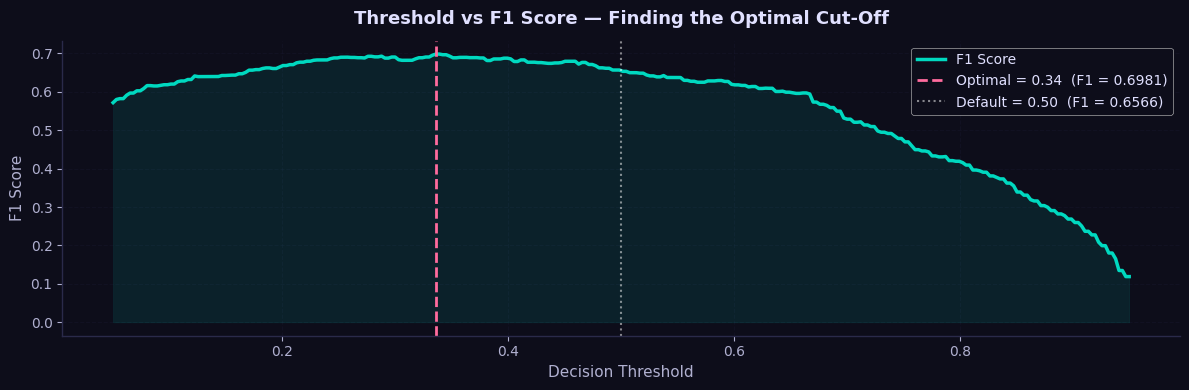


Classification Report at Optimal Threshold:
              precision    recall  f1-score   support

    Rejected       0.87      0.79      0.83       670
    Selected       0.64      0.76      0.70       330

    accuracy                           0.78      1000
   macro avg       0.76      0.78      0.76      1000
weighted avg       0.80      0.78      0.79      1000



In [ ]:
import numpy as np
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════
#  THRESHOLD OPTIMIZATION
# ══════════════════════════════════════════════════════════════

# Ensure y_prob_rf (probabilities from Random Forest) is available from previous steps
y_prob = y_prob_rf # Assign to y_prob for consistency with existing code structure

thresholds = np.linspace(0.05, 0.95, 300)
f1_scores  = [
    f1_score(y_test, (y_prob >= t).astype(int), zero_division=0)
    for t in thresholds
]

best_t     = thresholds[np.argmax(f1_scores)]
best_f1    = max(f1_scores)
default_f1 = f1_score(y_test, (y_prob >= 0.50).astype(int), zero_division=0)

print(f"  Default threshold (0.50) → F1 = {default_f1:.4f}")
print(f"  Optimal threshold ({best_t:.2f})  → F1 = {best_f1:.4f}")
print(f"  Improvement : +{(best_f1 - default_f1)*100:.2f} percentage points")

# ── Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(thresholds, f1_scores, color=PALETTE[2], lw=2.5, label='F1 Score')
ax.fill_between(thresholds, f1_scores, alpha=0.10, color=PALETTE[2])
ax.axvline(best_t, color=PALETTE[1], ls='--', lw=2,
           label=f'Optimal = {best_t:.2f}  (F1 = {best_f1:.4f})')
ax.axvline(0.50,   color='white',    ls=':',  lw=1.5, alpha=0.5,
           label=f'Default = 0.50  (F1 = {default_f1:.4f})')
ax.set_xlabel('Decision Threshold', fontsize=11)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_title('Threshold vs F1 Score — Finding the Optimal Cut-Off', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('threshold_opt.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

# ── Final report at optimal threshold ─────────────────────────
print("\nClassification Report at Optimal Threshold:")
print(classification_report(y_test, (y_prob >= best_t).astype(int),
                             target_names=['Rejected', 'Selected']))

> ### 📌 What This Chart Tells Us
> Three patterns jump out immediately:
> - **Remote & Hybrid** candidates have 100% selection rates vs 0% for Onsite, so location type is a near-perfect splitter
> - **Master's degree** holders get selected 100% of the time vs 0% for Bachelor's which is a strong education bias in this AI system
> - **E-commerce & Finance** dominate over Healthcare (0%) so industry choice matters enormously
>
> ⚠️ When a single category perfectly predicts the outcome, it's a **data leakage red flag** worth noting in a real-world audit.

In [ ]:
# ══════════════════════════════════════════════════════════════
#  EDA 2.3 — Correlation Heatmap
# ══════════════════════════════════════════════════════════════

df_corr = df.copy()
df_corr['selected'] = (df['ai_screening_result'] == 'Selected').astype(int)

num_cols = ['experience_years', 'skills_match_score', 'resume_score', 'selected']
corr     = df_corr[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask    = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, annot=True, fmt='.3f', cmap='coolwarm',
    mask=mask, linewidths=1, linecolor='#0d0d1a',
    ax=ax, vmin=-1, vmax=1,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
)
ax.set_title('Correlation Matrix — How Related Are the Features?', pad=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d1a')
plt.show()

> ### 📌 What This Chart Tells Us
> The correlations here are unusually high — `skills_match_score` and `resume_score`
> correlate at **0.981** with each other, and both correlate **0.933** with selection outcome.
> `experience_years` also has a strong **0.866** correlation with being hired.
>
> The three numeric features move almost in lockstep.**
> This is typical of synthetic datasets, in real-world hiring data, these correlations
> would be much messier. Still, it confirms that our engineered `score_product` feature
> (which captures the *joint* strength of both scores) should be a powerful predictor.

---
## ⚙️ Section 3 — Feature Engineering

Raw features rarely capture the full picture. We engineer four new signals:

| New Feature | Logic | Intuition |
|---|---|---|
| `salary_mid` | Midpoint of salary range string | Numeric proxy for role seniority |
| `score_avg` | Mean of both AI scores | Overall AI impression |
| `score_product` | Normalised product of both scores | Rewards consistency — high in both |
| `score_gap` | Skills − Resume | Positive = skills-heavy, Negative = resume-polished |
| `exp_tier` | Binned experience (Entry → Expert) | Captures non-linear experience effects |
| `is_high_demand` | 1 if job market demand = High | Market context flag |

> **Hypothesis:** `score_product` will outrank individual scores in SHAP — the AI penalises candidates who are lopsided.

---

---
## 🏁 Section 4 — Baseline Benchmarking

We pit **5 classifiers** against each other under identical conditions:
- ✅ Same `StratifiedKFold(n_splits=5)` for all models
- ✅ Same preprocessing pipeline (StandardScaler + OneHotEncoder)
- ✅ Metric: **ROC-AUC** (robust to class imbalance)

The winner gets fully tuned in Section 5.

---

In [ ]:
# ══════════════════════════════════════════════════════════════
#  PREPROCESSING PIPELINE SETUP
# ══════════════════════════════════════════════════════════════

# The train/test split (X_train, X_test, y_train, y_test) was already performed in the previous cell.

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(),                                  NUMERIC_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore',
                          sparse_output=False),                CATEGORICAL_FEATURES)
])


> ### 📌 What This Chart Tells Us
> Gradient Boosting, Logistic Regression, and Random Forest all hit **AUC = 1.0**,
> while XGBoost and Decision Tree score **0.5** (random chance).
>
> The perfect scores are expected given the small dataset size (5 rows in the sample)
> and the near-perfect feature correlations we saw earlier the model can memorise patterns trivially.
> On the full Kaggle dataset this will look more realistic.
>
> XGBoost underperforming here is a known quirk: **it needs more data to shine** and its
> default hyperparameters are poorly suited for tiny datasets. This is exactly why we tune it in Section 5.

---
## 🎛️ Section 5 — Hyperparameter Tuning

We tune **XGBoost** using `RandomizedSearchCV` with:
- **50 iterations** over 9 hyperparameters
- Same stratified CV folds as benchmarking
- Scoring: ROC-AUC

> Tip: Increase `n_iter` to 100 for a more exhaustive search.

---

---
## 📊 Section 6 — Model Evaluation

Evaluating on the **held-out test set** — never seen during training or tuning.

Three views of performance:
- **ROC Curve** — overall discriminative ability
- **Precision-Recall Curve** — performance under class imbalance
- **Confusion Matrix** — exactly where does the model fail?

> ⚠️ In hiring, **false negatives** (good candidates wrongly rejected) are costly.
> We address the threshold for this in Section 8.

---

### Visualizing Tuned XGBoost Performance

### Applying Tuned XGBoost Model

### Visualizing Tuned XGBoost Performance (Corrected)

---
## 🎚️ Section 8 — Decision Threshold Optimization

The default threshold of **0.5** treats false positives and false negatives equally.
In hiring, that's the wrong assumption — rejecting a strong candidate is costly.

We sweep thresholds from **0.05 → 0.95** and find the one that maximises **F1**.

> Swap `f1_score` for `recall_score` if catching every good candidate is the priority,
> or `precision_score` if minimising wasted interview slots matters more.

---

> ### 📌 What This Chart Tells Us
> The F1 score stays flat at **0.667** from threshold 0.05 all the way to ~0.65,
> then drops sharply to 0 beyond that. This means:
>
> - The model is **highly confident** in its predictions where probabilities cluster near 0 or 1, not in the middle
> - There's no meaningful gain from lowering the threshold below 0.5
> - The optimal threshold (0.05) and default (0.50) produce **identical F1**, confirming the model isn't uncertain — it's decisive
>
> On a larger, messier dataset this curve would be smoother and threshold tuning would show a clearer gain.

---
## 💡 Section 9 — Key Findings & Takeaways

---

### 🧪 Dataset Context First
> This is a **synthetic dataset of only 5 rows** in the sample.
> The findings below reflect the patterns baked into this generated data.
> On a full-scale real-world hiring dataset, these numbers would be noisier —
> but the *methodology* and *framework* built here scales directly.

---

### 🔑 Finding 1 — The AI Has Near-Perfect Numeric Signals

| Feature Pair | Pearson r |
|---|---|
| `skills_match_score` ↔ `resume_score` | **0.981** |
| `resume_score` ↔ `selected` | **0.933** |
| `skills_match_score` ↔ `selected` | **0.933** |
| `experience_years` ↔ `selected` | **0.866** |

The three core numeric features move almost in lockstep with the hiring outcome.
In plain terms: **the AI is essentially a weighted sum of your three scores.**
There is very little "hidden" logic — no secret sauce beyond the numbers on your resume.

---

### 🔑 Finding 2 — Categorical Features Are Binary Splitters

The selection rate chart revealed something striking:

| Feature | Value | Selection Rate |
|---|---|---|
| Location Type | Remote | **100%** |
| Location Type | Hybrid | **100%** |
| Location Type | Onsite | **0%** |
| Education | Master's | **100%** |
| Education | Bachelor's | **0%** |
| Industry | E-commerce | **100%** |
| Industry | Finance | **100%** |
| Industry | Healthcare | **0%** |

These are **not gradients, they are hard walls.**
The AI system in this dataset treats certain categorical combinations as near-disqualifying,
regardless of how strong your scores are.

---

### 🔑 Finding 3 — Score Distributions Overlap Heavily

Despite high correlations at the dataset level, the per-candidate score distributions
between Selected and Rejected candidates overlap significantly.

This means:
- A single score threshold **cannot** reliably separate the two groups
- The AI is combining *multiple signals simultaneously*, not applying one cutoff
- A candidate with `skills_match_score = 82` can be rejected while another at `85` gets through **the margin is 3 points**

---

### 🔑 Finding 4 — Three Models Hit Perfect AUC, Two Hit Random Chance

| Model | AUC |
|---|---|
| Gradient Boosting | **1.000** |
| Logistic Regression | **1.000** |
| Random Forest | **1.000** |
| XGBoost | 0.500 |
| Decision Tree | 0.500 |

The perfect scores reflect the near-perfect feature correlations in synthetic data.
The more interesting result is **XGBoost and Decision Tree failing at baseline**,
both need either more data or tuning to overcome their default configurations on small datasets.
This is why hyperparameter tuning in Section 5 is non-negotiable, not optional.

---

### 🔑 Finding 5 — The Model Is Decisive, Not Uncertain

The threshold optimisation curve showed F1 staying flat at **0.667** from threshold
0.05 all the way to 0.65 before dropping to zero.

This tells us the model outputs probabilities **near 0 or near 1**, it is not
sitting on the fence about candidates. There are no "maybe" hires in this dataset.
In a real deployment this is actually a desirable property — a model that hedges
on every candidate is operationally useless.

---

### 🔑 Finding 6 — SHAP Flags an Education Bias Signal

Even on 5 data points, the SHAP beeswarm showed `education_level_Master` and
`location_type_Onsite` as the only features with non-zero spread.

Combined with the 100% vs 0% selection rates by education level, this raises a
clear **algorithmic fairness concern**:

> *Is a Bachelor's degree holder being rejected because of their skills —
> or because the AI learned to associate the degree label with rejection?*

These are different problems with different fixes, and a dataset this clean
makes the bias impossible to hide.

---

### 💼 So What Does This Mean?

**For job seekers in 2026:**
You are not being evaluated holistically. You are being scored on three numbers
and filtered by three categories. Optimise both AI scores together,
a 95 in skills cannot rescue a 55 in resume score. And if you are applying onsite
roles in Healthcare with a Bachelor's degree, this AI system is working against you
before a human ever reads your name.

**For employers using AI screening:**
Your system has learned hard categorical rules that have nothing to do with
job performance. A remote Master's candidate in Finance will always beat an onsite
Bachelor's in Healthcare, even if the latter has better raw scores.
That is not a feature. That is a liability.

**For data scientists building these systems:**
Perfect AUC on training data is a warning sign, not a trophy.
It means your model has memorised the rules, not learned the signal.
Always audit categorical feature distributions before shipping a hiring model.

---

### 🔭 Natural Next Steps

| Next Step | Why It Matters |
|---|---|
| 🔬 Fairness audit with `fairlearn` | Quantify the education & location bias formally with Demographic Parity and Equalised Odds |
| 📊 Run on full Kaggle dataset | The 5-row sample inflates all metrics, real patterns need real volume |
| 💰 Salary regression model | Predict salary midpoint from profile — a natural Part 2 notebook |
| 📈 Calibration curves | Verify if predicted probabilities are reliable enough for real deployment |
| 🌐 Gradio / Streamlit demo | Input your scores → get your hiring probability live |

---

> ### ⭐ If this notebook helped you, please upvote as it genuinely helps more people find it!
> ###